# Spam Email Detector

In this project, I build a machine learning model that can classify SMS messages as either spam or normal messages.

The project will include:

- loading the SMS Spam Collection dataset
- exploring the data with basic visualizations
- cleaning the text
- converting text into TF-IDF features
- training Naive Bayes and Logistic Regression models
- evaluating the models with classification metrics
- testing the model on custom SMS messages

## 1. Import Libraries

First, I import the main libraries needed for loading and working with the dataset.

More libraries will be added later for visualization, preprocessing, vectorization, model training, and evaluation

In [1]:
from pathlib import Path

import pandas as pd

## 2. Define Dataset Path

The dataset file is stored in the `data` folder.

I am using the SMS Spam Collection dataset from the UCI Machine Learning Repository. The original file does not have a file extension, so it is saved as `spam`

In [2]:
DATA_PATH = Path("data/spam")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Please place the spam dataset file inside the data folder."
    )

## 3. Load Dataset

The dataset contains two main values:

- `label`: shows whether the message is `ham` or `spam`
- `message`: the SMS text

The UCI version of the dataset is tab-separated, so I use `sep="\t"` when loading it with pandas.

In [3]:
df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 4. Check Dataset Size

Now I check how many rows and columns are in the dataset.

In [4]:
df.shape

(5572, 2)

## 5. Check Dataset Information

This helps me understand the column types and whether the dataset was loaded correctly.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


## 6. Check Missing Values

Before analysis and modeling, I check if there are any missing values.

In [6]:
df.isna().sum()

label      0
message    0
dtype: int64

## 7. Preview Labels

I check how many messages belong to each class.
This is not the full analysis yet, but it gives a quick first look at the target variable.

In [7]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

## 8. Preview Random Messages

Finally, I look at a few random messages to understand what the text data looks like.

In [8]:
df.sample(5, random_state=42)

,label,message
3245,ham,Squeeeeeze!! This is christmas hug.. If u lik ...
944,ham,And also I've sorta blown him off a couple tim...
1044,ham,Mmm thats better now i got a roast down me! i...
2484,ham,Mm have some kanji dont eat anything heavy ok
812,ham,So there's a ring that comes with the guys cos...


## 9. Exploratory Data Analysis

The goal of this section is to understand:

- how many messages are spam and ham
- whether the dataset is balanced or imbalanced
- how message length differs between normal and spam messages

In [9]:
import matplotlib.pyplot as plt

## 10. Class Distribution

First, I check the number of messages in each class.

This is important because spam datasets are often imbalanced, meaning there are usually many more normal messages than spam messages.

In [10]:
class_counts = df["label"].value_counts()
class_counts

label
ham     4825
spam     747
Name: count, dtype: int64

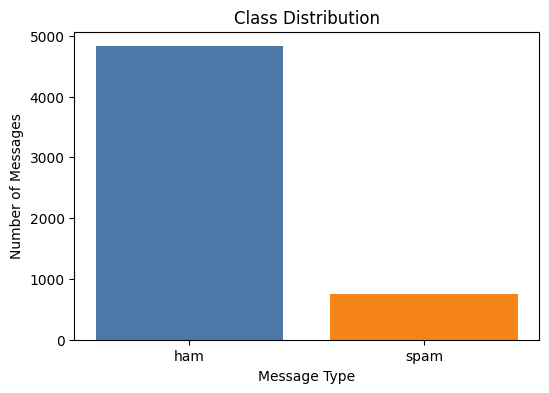

In [11]:
plt.figure(figsize=(6, 4))

# A bar chart makes it easier to compare the number of ham and spam messages.
plt.bar(class_counts.index, class_counts.values, color=["#4C78A8", "#F58518"])

plt.title("Class Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

## 11. Message Length Analysis

Next, I create a new column for message length.

This can help show whether spam messages tend to be longer or shorter than normal messages.

In [12]:
# I count the number of characters in each SMS message.
df["message_length"] = df["message"].apply(len)

df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [13]:
df["message_length"].describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: message_length, dtype: float64

## 12. Average Message Length by Class

Now I compare the average message length for `ham` and `spam` messages.

In [14]:
avg_length_by_class = df.groupby("label")["message_length"].mean()
avg_length_by_class

label
ham      71.482487
spam    138.670683
Name: message_length, dtype: float64

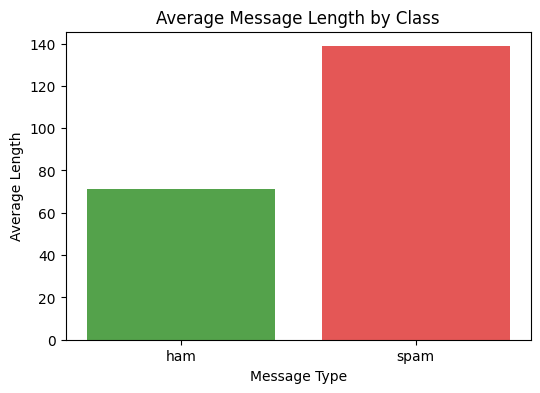

In [15]:
plt.figure(figsize=(6, 4))

plt.bar(
    avg_length_by_class.index,
    avg_length_by_class.values,
    color=["#54A24B", "#E45756"]
)

plt.title("Average Message Length by Class")
plt.xlabel("Message Type")
plt.ylabel("Average Length")

plt.show()

## 13. Message Length Distribution

A histogram gives a better view of how message lengths are distributed.

Here I compare the length distribution of `ham` and `spam` messages on the same plot.

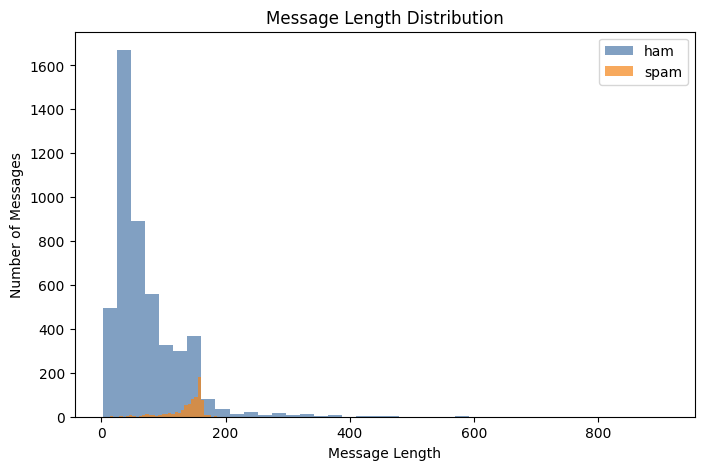

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["label"] == "ham"]["message_length"],
    bins=40,
    alpha=0.7,
    label="ham",
    color="#4C78A8"
)

plt.hist(
    df[df["label"] == "spam"]["message_length"],
    bins=40,
    alpha=0.7,
    label="spam",
    color="#F58518"
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Number of Messages")
plt.legend()

plt.show()

## 14. EDA Notes

The dataset contains more `ham` messages than `spam` messages.

Message length is also useful to inspect because spam messages often include offers, phone numbers, links, or instructions. 
This does not decide the final prediction by itself, but it helps understand the dataset before modeling.

## 15. Text Preprocessing

Machine learning models cannot understand raw text directly.

Before vectorizing the messages, I clean the text by:

- converting text to lowercase
- removing punctuation
- removing stopwords using NLTK

In [17]:
import string
import nltk

from nltk.corpus import stopwords

In [18]:
try:
    stopwords.words("english")
except LookupError:
    nltk.download("stopwords")

In [19]:
stop_words = set(stopwords.words("english"))

In [20]:
def clean_text(text):
    # Lowercase makes words like "Free" and "free" count as the same word.
    text = text.lower()
    
    # Removing punctuation keeps the text simpler for the model.
    text = "".join(char for char in text if char not in string.punctuation)
    
    # Stopwords are common words that usually do not add much meaning here.
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [21]:
df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## 16. Extra Text Features

Besides TF-IDF, I also add a few simple text-based features.

Spam messages often contain numbers, capital letters, exclamation marks, or longer text.

In [22]:
# These features are created from the original message text.
df["digit_count"] = df["message"].apply(lambda text: sum(char.isdigit() for char in text))
df["uppercase_count"] = df["message"].apply(lambda text: sum(char.isupper() for char in text))
df["exclamation_count"] = df["message"].apply(lambda text: text.count("!"))

df[["message_length", "digit_count", "uppercase_count", "exclamation_count"]].head()

,message_length,digit_count,uppercase_count,exclamation_count
0,111,0,3,0
1,29,0,2,0
2,155,25,10,0
3,49,0,2,0
4,61,0,2,0


## 17. TF-IDF Vectorization

TF-IDF converts cleaned text into numbers so the models can use it.

I use both single words and two-word phrases. This helps the model learn patterns like 'free prize', 'call now', and 'urgent reply'.

In [23]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [24]:
X_text = df["clean_message"]
X_extra = df[["message_length", "digit_count", "uppercase_count", "exclamation_count"]]
y = df["label"]

In [25]:
X_text_train, X_text_test, X_extra_train, X_extra_test, y_train, y_test = train_test_split(
    X_text,
    X_extra,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
tfidf = TfidfVectorizer(
    max_features=5000,      # I keep the top 5000 terms to give the model more useful words.
    ngram_range=(1, 2)      # This lets the model learn single words and two-word phrases.
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

In [27]:
X_train_features = hstack([X_train_tfidf, X_extra_train])
X_test_features = hstack([X_test_tfidf, X_extra_test])

X_train_features.shape, X_test_features.shape

((4457, 5004), (1115, 5004))

## 17. Model Training

Now I train two machine learning models:

- Naive Bayes
- Logistic Regression

Both models are commonly used for text classification tasks.

In [28]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

## 18. Naive Bayes Model

Naive Bayes is often a strong baseline model for spam detection and other text classification problems.

In [29]:
nb_model = MultinomialNB()

# Naive Bayes works well with TF-IDF features, so I train it only on the TF-IDF matrix.
nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [30]:
nb_predictions = nb_model.predict(X_test_tfidf)

nb_predictions[:10]

array(['ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham'], dtype='<U4')

## 19. Logistic Regression Model

Logistic Regression is another strong model for text classification. It works well with TF-IDF features.

In [31]:
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")

# class_weight="balanced" helps the model pay more attention to the smaller spam class.
lr_model.fit(X_train_features, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [32]:
lr_predictions = lr_model.predict(X_test_features)

lr_predictions[:10]

array(['ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham'], dtype=object)

## 20. Model Evaluation

Now I evaluate both models.

Because the dataset is imbalanced, I use accuracy, precision, recall, F1-score, and confusion matrices.

In [33]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 21. Naive Bayes Evaluation

In [34]:
nb_accuracy = accuracy_score(y_test, nb_predictions)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print()
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 0.9704

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



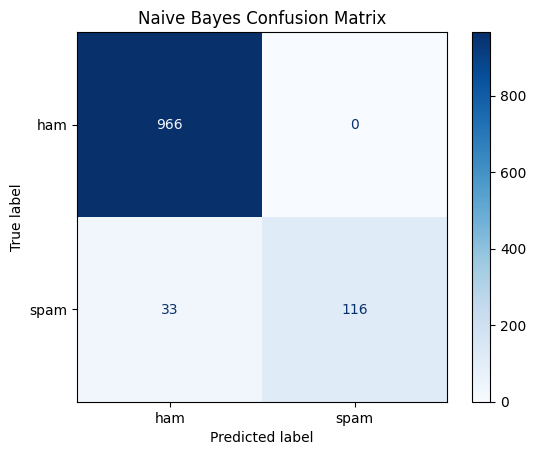

In [35]:
nb_cm = confusion_matrix(y_test, nb_predictions, labels=["ham", "spam"])

nb_display = ConfusionMatrixDisplay(
    confusion_matrix=nb_cm,
    display_labels=["ham", "spam"]
)

nb_display.plot(cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Naive Bayes performs well as a baseline model. It correctly classifies most normal messages and catches many spam messages.

The model has very high spam precision, which means that when it predicts a message as spam, it is usually correct. However, 
it still misses some spam messages, so spam recall is the main area that could be improved.

## 22. Logistic Regression Evaluation

In [36]:
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print()
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.9776

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.91      0.92      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



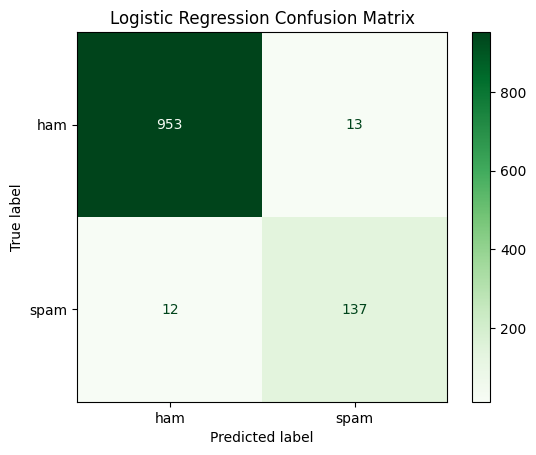

In [37]:
lr_cm = confusion_matrix(y_test, lr_predictions, labels=["ham", "spam"])

lr_display = ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["ham", "spam"]
)

lr_display.plot(cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Logistic Regression gives the best overall result in this version of the project.

It catches more spam messages than Naive Bayes and still keeps false spam predictions relatively low. 
This makes it a better final model for this spam detector.

## 23. Final Accuracy Comparison

Overall, both models perform well, but Logistic Regression gives the stronger final result.

Naive Bayes is a good baseline model, while Logistic Regression performs better after using TF-IDF together with the extra text features.
For this project, Logistic Regression is selected as the final model.
Finally, I print the final accuracy for both models in one place.

In [38]:
print(f"Naive Bayes Final Accuracy: {nb_accuracy:.4f}")
print(f"Logistic Regression Final Accuracy: {lr_accuracy:.4f}")

Naive Bayes Final Accuracy: 0.9704
Logistic Regression Final Accuracy: 0.9776


## 24. Custom SMS Prediction Demo

Finally, I create a small function that can classify a new SMS message as ham or spam

In [39]:
def predict_sms(message, model=lr_model):  # Logistic Regression by default
    clean_message = clean_text(message)
    message_tfidf = tfidf.transform([clean_message])
    
    extra_features = pd.DataFrame([{
        "message_length": len(message),
        "digit_count": sum(char.isdigit() for char in message),
        "uppercase_count": sum(char.isupper() for char in message),
        "exclamation_count": message.count("!")
    }])
    
    final_features = hstack([message_tfidf, extra_features])
    prediction = model.predict(final_features)[0]
    
    return prediction

In [40]:
test_message = "Congratulations! You won a free prize. Call now to claim."

predict_sms(test_message)

'ham'

In [41]:
test_message = "Hey, are we still meeting today?"

predict_sms(test_message)

'ham'

In [42]:
# Run this part with Shift + Enter to input your message.
user_message = input("Enter an SMS message: ")

prediction = predict_sms(user_message)

print(f"Prediction: {prediction}")

Enter an SMS message:  hello


Prediction: ham
